In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.signal import savgol_filter
from scan_spectrolyser import scan_helpers
from scan_spectrolyser import no3_calibrations

In [33]:
def fit_linear_function(linear_range, x, y):
    coeff = np.polyfit(linear_range[x], linear_range[y], 1)
    r2 = np.corrcoef(linear_range[x], linear_range[y])[0,1]**2
    return coeff, r2

def plot_linear_fit(data, linear_range, x, y, text_start_x, text_start_y, text_y_spacing, ax):
    coeff, r2 = fit_linear_function(linear_range, x, y)
    vals= np.polyval(coeff, data[x])
    ax.plot(data[x], vals, color='b')
    ax.text(text_start_x, text_start_y, 'Slope: %.4f' % (coeff[0]))
    ax.text(text_start_x, text_start_y - text_y_spacing, 'Intercept: %.4f' % (coeff[1]))
    ax.text(text_start_x, text_start_y - 2*text_y_spacing, 'R2: %.4f' % (r2))
    return coeff, r2

# Chinese S::CAN

## New calibration with freshly made standards

In [13]:
chinesecal_21425 = scan_helpers.import_scan_fp('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/SCAN Calibration 2-14-25/calibration.fp')
chinesecal_21425['Concentration (mg/L)'] = [0, .01, .05, .1, .5, 1, 2]
chinesecal_21425 = scan_helpers.apply_calibrations(chinesecal_21425, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

chinesecal_21425

,Date/Time,200.00,202.50,205.00,207.50,210.00,212.50,215.00,217.50,220.00,...,737.50,740.00,742.50,745.00,747.50,750.00,Concentration (mg/L),one_wavelength,two_wavelength,second_derivative
0,2025-02-14 20:30:12,0.0826,0.0666,0.0752,0.0589,0.0508,0.0435,0.0547,0.0473,0.0295,...,-0.0128,0.0118,NaN,NaN,NaN,NaN,0.00,0.0295,-0.0209,0.0106
1,2025-02-14 20:34:52,1.2288,1.1535,1.1026,1.0453,0.9938,0.9029,0.8143,0.7459,0.6475,...,0.3067,0.3444,NaN,NaN,NaN,NaN,0.01,0.6475,-0.1547,0.0546
2,2025-02-14 20:37:53,3.0861,2.9880,2.8668,2.6985,2.4761,2.1849,1.8454,1.4472,1.0724,...,-0.0794,-0.0317,NaN,NaN,NaN,NaN,0.05,1.0724,1.0412,0.0972
3,2025-02-14 20:42:10,5.6545,5.5738,5.4064,5.1191,4.6868,4.1372,3.4624,2.7219,2.0223,...,-0.0739,-0.1229,NaN,NaN,NaN,NaN,0.10,2.0223,2.0275,0.1920
4,2025-02-14 20:46:16,25.8739,25.1909,24.5774,23.5559,21.6885,19.2265,16.1961,12.8890,9.8394,...,0.1678,0.2025,NaN,NaN,NaN,NaN,0.50,9.8394,9.3758,0.8514
5,2025-02-14 20:49:50,40.1535,37.9057,37.2848,36.6465,34.8239,31.6588,27.3037,22.4632,18.0745,...,-0.0655,-0.0687,NaN,NaN,NaN,NaN,1.00,18.0745,17.9325,1.5279
6,2025-02-14 20:53:45,44.3181,41.7555,41.4887,41.2649,39.9088,37.5216,33.8745,30.1624,26.9851,...,-0.1614,-0.0460,NaN,NaN,NaN,NaN,2.00,26.9851,26.9005,2.2437


(array([ 0.60215605, -0.01321595]), 0.9990423663515184)

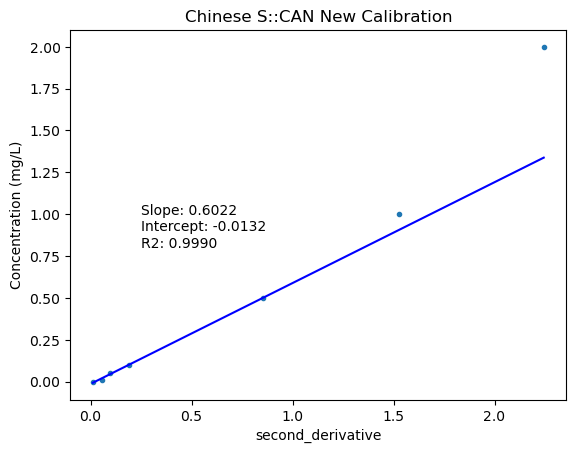

In [35]:
fig, ax = plt.subplots()
chinesecal_21425.plot(y='Concentration (mg/L)', x='second_derivative', marker='.', linestyle = 'None', title = 'Chinese S::CAN New Calibration', ylabel = 'Concentration (mg/L)', legend=False, ax=ax)
plot_linear_fit(chinesecal_21425, chinesecal_21425[0:5], 'second_derivative', 'Concentration (mg/L)', .25, 1, .1, ax=ax)

- This calibration looks great! 
- linear up until 0.5 mg/L, non linear above that - will have to check with turbidity if still linear.
- for reference, in Reynolds we were seeing ~ 10 uM (.14 mg/L). So this range seems very reasonable

## Calibration made with old standards
- these are based off of erroneous SEAL standard

In [80]:
chinesecal_21425_old = scan_helpers.import_scan_fp('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/SCAN Calibration 2-14-25/calibration_old.fp')
chinesecal_21425_old['Concentration (mg/L)'] = [0, .01, .05, .1, .5, 1, 2]
chinesecal_21425_old['Concentration (mg/L) Correct'] = chinesecal_21425_old['Concentration (mg/L)']*1.168
chinesecal_21425_old = scan_helpers.apply_calibrations(chinesecal_21425_old, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

chinesecal_21425_old

,Date/Time,200.00,202.50,205.00,207.50,210.00,212.50,215.00,217.50,220.00,...,740.00,742.50,745.00,747.50,750.00,Concentration (mg/L),Concentration (mg/L) Correct,one_wavelength,two_wavelength,second_derivative
0,2025-02-14 20:30:12,0.0826,0.0666,0.0752,0.0589,0.0508,0.0435,0.0547,0.0473,0.0295,...,0.0118,NaN,NaN,NaN,NaN,0.00,0.00000,0.0295,-0.0209,0.0106
1,2025-02-14 20:32:44,0.9898,0.9099,0.8402,0.7612,0.6769,0.5760,0.4679,0.3740,0.2757,...,-0.0520,NaN,NaN,NaN,NaN,0.01,0.01168,0.2757,0.3057,0.0392
2,2025-02-14 20:36:24,3.3421,3.2198,3.1041,2.9418,2.6811,2.3687,1.9869,1.5580,1.1399,...,-0.1024,NaN,NaN,NaN,NaN,0.05,0.05840,1.1399,1.1881,0.1101
3,2025-02-14 20:40:01,6.7109,6.4952,6.2287,5.8864,5.3939,4.7647,4.0020,3.1616,2.3735,...,-0.0551,NaN,NaN,NaN,NaN,0.10,0.11680,2.3735,2.4005,0.2138
4,2025-02-14 20:43:57,28.8335,27.9208,27.2758,26.1644,24.1168,21.3558,17.9926,14.2989,10.9275,...,-0.1090,NaN,NaN,NaN,NaN,0.50,0.58400,10.9275,10.9451,0.9249
5,2025-02-14 20:48:01,41.3728,38.9901,38.3699,37.5544,35.8920,33.0198,28.7738,23.9314,19.4243,...,-0.0791,NaN,NaN,NaN,NaN,1.00,1.16800,19.4243,19.2875,1.6499
6,2025-02-14 20:51:24,44.7316,42.3289,41.7741,41.7697,40.4850,38.2216,34.7732,31.1748,28.5334,...,-0.0001,NaN,NaN,NaN,NaN,2.00,2.33600,28.5334,28.3468,2.2607


(array([ 0.60215605, -0.01321595]), 0.9990423663515184)

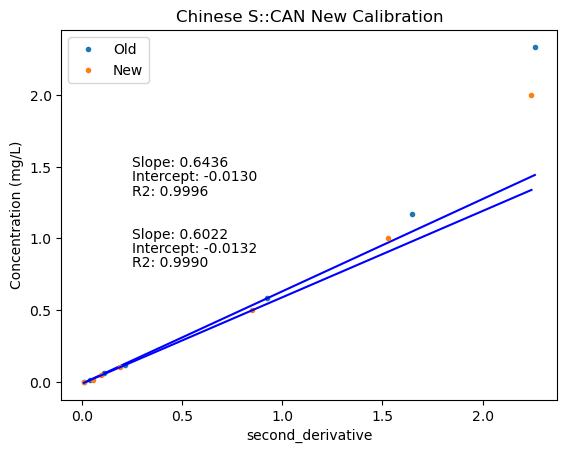

In [81]:
fig, ax = plt.subplots()
chinesecal_21425_old.plot(y='Concentration (mg/L) Correct', x='second_derivative', marker='.', linestyle = 'None', title = 'Chinese S::CAN Old Calibration', ylabel = 'Concentration (mg/L)', label='Old', ax=ax)
plot_linear_fit(chinesecal_21425_old, chinesecal_21425_old[0:5], 'second_derivative', 'Concentration (mg/L) Correct', .25, 1.5, .1, ax=ax)

chinesecal_21425.plot(y='Concentration (mg/L)', x='second_derivative', marker='.', linestyle = 'None', title = 'Chinese S::CAN New Calibration', ylabel = 'Concentration (mg/L)', label='New', ax=ax)
plot_linear_fit(chinesecal_21425, chinesecal_21425[0:5], 'second_derivative', 'Concentration (mg/L)', .25, 1, .1, ax=ax)

- why don't old and new calibration curves match up when corrected? the correction factor for the old standards seems to be 1.1, not 1.168 as the last standard run would indicate... 

# Ocean S::CAN

In [72]:
oceancal_12225 = scan_helpers.import_scan_fp('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/SCAN Calibration 1-22-25/calibration.fp')
oceancal_12225['Concentration (mg/L)'] = [0, .01, .05, .1, .5, 1, 2]
oceancal_12225['Concentration (mg/L) Correct'] = oceancal_12225['Concentration (mg/L)']*1.168
oceancal_12225 = scan_helpers.apply_calibrations(oceancal_12225, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

oceancal_12225

,Date/Time,200.00,202.50,205.00,207.50,210.00,212.50,215.00,217.50,220.00,...,740.00,742.50,745.00,747.50,750.00,Concentration (mg/L),Concentration (mg/L) Correct,one_wavelength,two_wavelength,second_derivative
0,2025-01-22 16:40:24,0.3255,0.2764,0.2415,0.2023,0.1696,0.1687,0.1706,0.1630,0.1607,...,NaN,NaN,NaN,NaN,NaN,0.00,0.00000,0.1607,0.0005,0.0036
1,2025-01-22 17:41:44,-0.1965,-0.0878,-0.0238,-0.0172,-0.0242,-0.0335,-0.0561,-0.0801,-0.1039,...,NaN,NaN,NaN,NaN,NaN,0.01,0.01168,-0.1039,0.1309,0.0059
2,2025-01-22 17:45:36,2.6466,2.7199,2.6999,2.5548,2.2905,1.9838,1.6464,1.2902,0.9614,...,NaN,NaN,NaN,NaN,NaN,0.05,0.05840,0.9614,1.1026,0.0854
3,2025-01-22 17:48:07,5.9337,5.9977,5.8984,5.5549,4.9748,4.2868,3.5447,2.8134,2.1695,...,NaN,NaN,NaN,NaN,NaN,0.10,0.11680,2.1695,2.3387,0.1901
4,2025-01-22 17:50:39,28.7683,28.8894,28.0997,26.0091,22.8880,19.7833,16.8565,13.8807,11.0725,...,NaN,NaN,NaN,NaN,NaN,0.50,0.58400,11.0725,11.3563,0.9694
5,2025-01-22 17:53:06,39.8499,40.2908,39.4377,36.3946,32.3622,29.2789,26.8136,23.9366,20.4171,...,NaN,NaN,NaN,NaN,NaN,1.00,1.16800,20.4171,20.4859,1.7251
6,2025-01-22 17:55:30,42.8878,43.4913,42.7721,39.7692,35.9325,33.3872,32.2544,31.9902,31.1693,...,NaN,NaN,NaN,NaN,NaN,2.00,2.33600,31.1693,31.4275,2.4695


(array([0.5983311 , 0.00406669]), 0.9997206842506537)

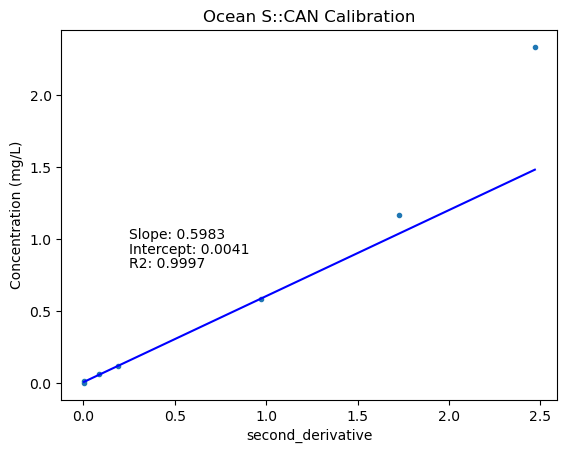

In [73]:
fig, ax = plt.subplots()
oceancal_12225.plot(y='Concentration (mg/L) Correct', x='second_derivative', marker='.', linestyle = 'None', title = 'Ocean S::CAN Calibration', ylabel = 'Concentration (mg/L)', legend=False, ax=ax)
plot_linear_fit(oceancal_12225, oceancal_12225[0:5], 'second_derivative', 'Concentration (mg/L) Correct', .25, 1, .1, ax=ax)


- calibration for the ocean s::Can (current at RME) also looks good - linear to .5 mg/L, LOD somewhere betweenm .01 and .05 mg/L (expected is .14)